# 02 - Weather Data Integration

## Objective
Fetch historical + forward weather data for the 5 active Club Piscine store cities.

## Store Cities (from Table_Magasins)
| Store | City | Province |
|---|---|---|
| CP08 | Longueuil | QC |
| CP37 | Gatineau | QC |
| CP44 | St-Constant | QC |
| CP48 | Beloeil | QC |
| CP202 | Nepean (Ottawa) | ON |

## Data Sources
- **Open-Meteo Archive API** — historical daily weather (free, no key)
- **Open-Meteo Forecast API** — up to 16 days ahead (free, no key)
- **python-holidays** — Quebec + Ontario statutory holidays

## Input
- `data/processed/weekly_sales.csv`

## Output
- `data/processed/weather_by_city_week.csv`
- `data/processed/weekly_sales_weather.csv`
---

---
## Cell 1: Imports and Setup
---

In [1]:
import pandas as pd
import numpy as np
import requests
import holidays as holidays_lib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
print('✅ Imports complete')

✅ Imports complete


---
## Cell 2: City Configuration
---

In [2]:
weekly = pd.read_csv(DATA_PROCESSED / 'weekly_sales.csv')
weekly['week_ending'] = pd.to_datetime(weekly['week_ending'])
print(f'Weekly sales loaded: {weekly.shape}')

CITY_COORDS = {
    'Longueuil':   {'lat': 45.5317, 'lon': -73.5180, 'province': 'QC', 'store': 'CP08'},
    'Gatineau':    {'lat': 45.4765, 'lon': -75.7013, 'province': 'QC', 'store': 'CP37'},
    'St-Constant': {'lat': 45.3688, 'lon': -73.5698, 'province': 'QC', 'store': 'CP44'},
    'Beloeil':     {'lat': 45.5638, 'lon': -73.2052, 'province': 'QC', 'store': 'CP48'},
    'Nepean':      {'lat': 45.3192, 'lon': -75.7166, 'province': 'ON', 'store': 'CP202'},
}

START_DATE    = weekly['week_ending'].min().strftime('%Y-%m-%d')
END_DATE      = weekly['week_ending'].max().strftime('%Y-%m-%d')
FORECAST_DAYS = 16

print(f'📅 Historical range : {START_DATE} → {END_DATE}')
print(f'🔮 Forward forecast : {FORECAST_DAYS} days')
print(f'🏙️  Cities           : {list(CITY_COORDS.keys())}')

Weekly sales loaded: (1333, 7)
📅 Historical range : 2025-06-08 → 2025-09-14
🔮 Forward forecast : 16 days
🏙️  Cities           : ['Longueuil', 'Gatineau', 'St-Constant', 'Beloeil', 'Nepean']


---
## Cell 3: Weather Classification (WMO Codes)
---

In [3]:
def classify_weather(df):
    """
    Map WMO weather codes to conditions and binary flags.
    Reference: https://open-meteo.com/en/docs#weathervariables
    """
    def get_condition(code):
        if   code == 0:                return 'Clear'
        elif code in range(1, 4):      return 'Cloudy'
        elif code in range(45, 50):    return 'Fog'
        elif code in range(51, 68):    return 'Rain'
        elif code in range(71, 78):    return 'Snow'
        elif code in range(80, 83):    return 'Rain'
        elif code in range(85, 87):    return 'Snow'
        elif code in range(95, 100):   return 'Thunderstorm'
        else:                           return 'Other'

    df = df.copy()
    df['weather_condition'] = df['weathercode'].apply(get_condition)
    df['is_rain']            = (df['weather_condition'] == 'Rain').astype(int)
    df['is_snow']            = (df['weather_condition'] == 'Snow').astype(int)
    df['is_bad_weather']     = df['weather_condition'].isin(
        ['Rain', 'Snow', 'Thunderstorm', 'Fog']).astype(int)
    return df

print('✅ classify_weather() defined')

✅ classify_weather() defined


---
## Cell 4: Fetch Historical Weather
---

In [4]:
def fetch_historical_weather(city, lat, lon, start_date, end_date):
    url    = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': lat, 'longitude': lon,
        'start_date': start_date, 'end_date': end_date,
        'daily': ['temperature_2m_mean','temperature_2m_max',
                  'precipitation_sum','weathercode','sunshine_duration'],
        'timezone': 'America/Toronto'
    }
    r    = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()['daily']
    df   = pd.DataFrame({
        'date':           pd.to_datetime(data['time']),
        'temp_mean':      data['temperature_2m_mean'],
        'temp_max':       data['temperature_2m_max'],
        'precipitation':  data['precipitation_sum'],
        'weathercode':    [int(c) for c in data['weathercode']],
        'sunshine_hours': [s/3600 if s else 0 for s in data['sunshine_duration']],
        'city': city
    }).fillna(0)
    return classify_weather(df)


all_hist = []
for city, coords in CITY_COORDS.items():
    print(f'  Fetching historical: {city}...')
    try:
        df = fetch_historical_weather(city, coords['lat'], coords['lon'], START_DATE, END_DATE)
        all_hist.append(df)
        print(f'    ✓ {len(df)} days')
    except Exception as e:
        print(f'    ✗ Failed: {e}')

weather_daily = pd.concat(all_hist, ignore_index=True)
print(f'\n✅ Historical weather: {weather_daily.shape[0]:,} daily records')

  Fetching historical: Longueuil...
    ✓ 99 days
  Fetching historical: Gatineau...
    ✓ 99 days
  Fetching historical: St-Constant...
    ✓ 99 days
  Fetching historical: Beloeil...
    ✓ 99 days
  Fetching historical: Nepean...
    ✓ 99 days

✅ Historical weather: 495 daily records


---
## Cell 5: Fetch Forward Forecast (16 days)
---

In [5]:
def fetch_forecast_weather(city, lat, lon, forecast_days=16):
    url    = 'https://api.open-meteo.com/v1/forecast'
    params = {
        'latitude': lat, 'longitude': lon,
        'daily': ['temperature_2m_mean','temperature_2m_max',
                  'precipitation_sum','weathercode','sunshine_duration'],
        'timezone': 'America/Toronto',
        'forecast_days': forecast_days
    }
    r    = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()['daily']
    df   = pd.DataFrame({
        'date':           pd.to_datetime(data['time']),
        'temp_mean':      data['temperature_2m_mean'],
        'temp_max':       data['temperature_2m_max'],
        'precipitation':  data['precipitation_sum'],
        'weathercode':    [int(c) for c in data['weathercode']],
        'sunshine_hours': [s/3600 if s else 0 for s in data['sunshine_duration']],
        'city': city
    }).fillna(0)
    return classify_weather(df)


all_fcast = []
for city, coords in CITY_COORDS.items():
    print(f'  Fetching forecast: {city}...')
    try:
        df = fetch_forecast_weather(city, coords['lat'], coords['lon'], FORECAST_DAYS)
        all_fcast.append(df)
        print(f'    ✓ {len(df)} days ahead')
    except Exception as e:
        print(f'    ✗ Failed: {e}')

weather_fcast_daily = pd.concat(all_fcast, ignore_index=True)
print(f'\n✅ Forecast weather: {weather_fcast_daily.shape[0]:,} daily records')

  Fetching forecast: Longueuil...
    ✓ 16 days ahead
  Fetching forecast: Gatineau...
    ✓ 16 days ahead
  Fetching forecast: St-Constant...
    ✓ 16 days ahead
  Fetching forecast: Beloeil...
    ✓ 16 days ahead
  Fetching forecast: Nepean...
    ✓ 16 days ahead

✅ Forecast weather: 80 daily records


---
## Cell 6: Aggregate to Weekly
---

In [6]:
def aggregate_weather_weekly(df):
    return (
        df.set_index('date')
          .groupby('city')
          .resample('W')
          .agg(
              avg_temp         = ('temp_mean',     'mean'),
              max_temp         = ('temp_max',       'max'),
              total_precip     = ('precipitation',  'sum'),
              sunshine_hours   = ('sunshine_hours', 'sum'),
              rain_days        = ('is_rain',        'sum'),
              snow_days        = ('is_snow',        'sum'),
              bad_weather_days = ('is_bad_weather', 'sum')
          )
          .reset_index()
          .rename(columns={'date': 'week_ending'})
    )

hist_weekly  = aggregate_weather_weekly(weather_daily)
fcast_weekly = aggregate_weather_weekly(weather_fcast_daily)

weather_weekly = (
    pd.concat([hist_weekly, fcast_weekly], ignore_index=True)
      .drop_duplicates(subset=['city','week_ending'])
      .sort_values(['city','week_ending'])
      .reset_index(drop=True)
)
num_cols = weather_weekly.select_dtypes(include=np.number).columns
weather_weekly[num_cols] = weather_weekly[num_cols].round(2)

print(f'Weekly weather: {weather_weekly.shape}')
print(f'Date range: {weather_weekly["week_ending"].min().date()} → {weather_weekly["week_ending"].max().date()}')
weather_weekly.head()

Weekly weather: (90, 9)
Date range: 2025-06-08 → 2026-03-22


,city,week_ending,avg_temp,max_temp,total_precip,sunshine_hours,rain_days,snow_days,bad_weather_days
0,Beloeil,2025-06-08,18.20,24.0,0.0,13.70,0,0,0
1,Beloeil,2025-06-15,17.04,23.8,8.3,87.57,4,0,4
2,Beloeil,2025-06-22,21.24,28.6,53.1,76.40,5,0,5
3,Beloeil,2025-06-29,21.94,33.3,35.2,76.26,5,0,5
4,Beloeil,2025-07-06,21.63,30.9,54.3,82.10,5,0,5


---
## Cell 7: Quebec & Ontario Holidays
---

In [7]:
years_in_data = sorted(weekly['week_ending'].dt.year.unique().tolist())
city_province = {city: v['province'] for city, v in CITY_COORDS.items()}

hol_records = []
for prov in ['QC', 'ON']:
    for date, name in holidays_lib.Canada(prov=prov, years=years_in_data).items():
        hol_records.append({'date': pd.Timestamp(date), 'holiday': name, 'province': prov})

holidays_df = pd.DataFrame(hol_records)
holidays_df['week_ending'] = holidays_df['date'] + pd.offsets.Week(weekday=6)

city_prov_df = pd.DataFrame([{'city': c, 'province': p} for c, p in city_province.items()])
holiday_weekly = (
    holidays_df.merge(city_prov_df, on='province')
               .groupby(['city','week_ending'])
               .agg(n_holidays=('holiday','count'), has_holiday=('holiday', lambda x: 1))
               .reset_index()
)
print(f'✅ {len(holidays_df)} holiday records (QC + ON)')

✅ 17 holiday records (QC + ON)


---
## Cell 8: Merge Weather + Holidays onto Sales
---

In [8]:
weekly_weather = weekly.merge(weather_weekly, on=['city','week_ending'], how='left')
weekly_weather = weekly_weather.merge(
    holiday_weekly[['city','week_ending','n_holidays','has_holiday']],
    on=['city','week_ending'], how='left'
)
weekly_weather['n_holidays']  = weekly_weather['n_holidays'].fillna(0).astype(int)
weekly_weather['has_holiday'] = weekly_weather['has_holiday'].fillna(0).astype(int)

# Fill weather gaps with monthly median per city
weekly_weather['month'] = weekly_weather['week_ending'].dt.month
for col in ['avg_temp','total_precip','rain_days','snow_days','bad_weather_days','sunshine_hours']:
    if col in weekly_weather.columns:
        med = weekly_weather.groupby(['city','month'])[col].transform('median')
        weekly_weather[col] = weekly_weather[col].fillna(med)

print(f'Merged dataset: {weekly_weather.shape}')

Merged dataset: (1333, 17)


---
## Cell 9: Weather vs Sales Visualizations
---

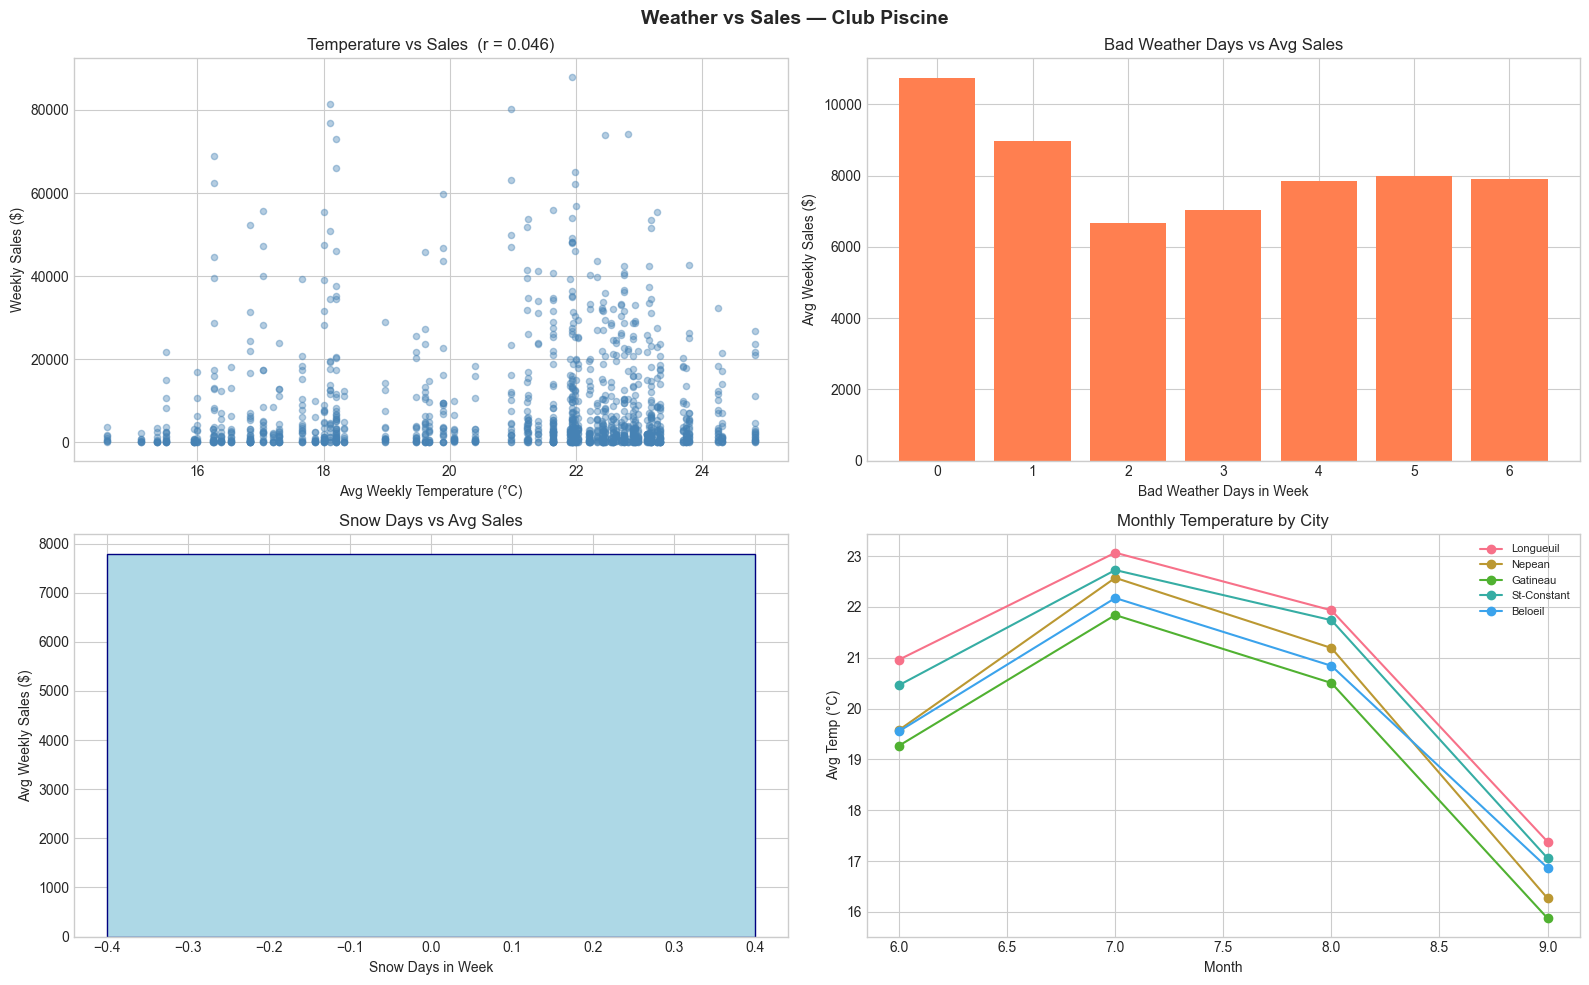

✅ Saved: weather_vs_sales.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax1 = axes[0, 0]
ax1.scatter(weekly_weather['avg_temp'], weekly_weather['sales'], alpha=0.4, color='steelblue', s=20)
corr = weekly_weather['avg_temp'].corr(weekly_weather['sales'])
ax1.set_xlabel('Avg Weekly Temperature (°C)')
ax1.set_ylabel('Weekly Sales ($)')
ax1.set_title(f'Temperature vs Sales  (r = {corr:.3f})')

ax2 = axes[0, 1]
bw = weekly_weather.groupby('bad_weather_days')['sales'].mean()
ax2.bar(bw.index, bw.values, color='coral')
ax2.set_xlabel('Bad Weather Days in Week')
ax2.set_ylabel('Avg Weekly Sales ($)')
ax2.set_title('Bad Weather Days vs Avg Sales')

ax3 = axes[1, 0]
sn = weekly_weather.groupby('snow_days')['sales'].mean()
ax3.bar(sn.index, sn.values, color='lightblue', edgecolor='navy')
ax3.set_xlabel('Snow Days in Week')
ax3.set_ylabel('Avg Weekly Sales ($)')
ax3.set_title('Snow Days vs Avg Sales')

ax4 = axes[1, 1]
for city in weekly_weather['city'].dropna().unique():
    d = weekly_weather[weekly_weather['city']==city].groupby('month')['avg_temp'].mean()
    ax4.plot(d.index, d.values, marker='o', label=city)
ax4.set_xlabel('Month')
ax4.set_ylabel('Avg Temp (°C)')
ax4.set_title('Monthly Temperature by City')
ax4.legend(fontsize=8)

plt.suptitle('Weather vs Sales — Club Piscine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'weather_vs_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: weather_vs_sales.png')

---
## Cell 10: Save Outputs
---

In [10]:
weather_weekly.to_csv(DATA_PROCESSED / 'weather_by_city_week.csv', index=False)
weekly_weather.to_csv(DATA_PROCESSED / 'weekly_sales_weather.csv', index=False)
print(f'✅ Saved: weather_by_city_week.csv  ({weather_weekly.shape})')
print(f'✅ Saved: weekly_sales_weather.csv  ({weekly_weather.shape})')
print('Next → 03_feature_engineering.ipynb')

✅ Saved: weather_by_city_week.csv  ((90, 9))
✅ Saved: weekly_sales_weather.csv  ((1333, 17))
Next → 03_feature_engineering.ipynb
